# Baseline Model - Random Forest

Before building any GNN, we establish a strong tabular baseline using Random Forest.
This is critical: if a simple model on raw features performs well, 
it means the graph structure adds limited value. We need to know this before investing
time in more complex models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score
import torch
from torch_geometric.datasets import EllipticBitcoinDataset

# Load dataset
dataset = EllipticBitcoinDataset(root='../data/elliptic')
data = dataset[0]

# Load timesteps from raw data
feat_df = pd.read_csv('../data/elliptic/raw/elliptic_txs_features.csv', header=None)
class_df = pd.read_csv('../data/elliptic/raw/elliptic_txs_classes.csv')
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1, feat_df.shape[1])]
feat_df['timestep'] = feat_df['f1'].astype(int)
class_df.columns = ['txId', 'label']
df_meta = feat_df[['txId', 'timestep']].merge(class_df, on='txId')

print("Data loaded")
print(f"Nodes: {data.num_nodes:,} | Features: {data.num_node_features}")

Data loaded
Nodes: 203,769 | Features: 165


## 1. Temporal Train/Test Split

We split the data temporally: train on timesteps 1-34, test on 35-49.
This mirrors real-world conditions where a model trained on past fraud 
must generalize to future, unseen fraud patterns.

A random split would leak future information into training, giving artificially good results that wouldn't hold in production.

In [2]:
# Temporal train/test split
# Train on timesteps 1-34, test on 35-49 (same split used in the original paper)
X = data.x.numpy()
y = data.y.numpy()
timesteps = df_meta['timestep'].values

# Only use labeled nodes (exclude unknown = 0)
labeled_mask = y != 0
X_labeled = X[labeled_mask]
y_labeled = y[labeled_mask]
t_labeled = timesteps[labeled_mask]

# Convert labels: 1=illicit, 2=licit → 1=illicit, 0=licit
y_binary = (y_labeled == 1).astype(int)

# Temporal split
train_mask = t_labeled <= 34
test_mask = t_labeled > 34

X_train, y_train = X_labeled[train_mask], y_binary[train_mask]
X_test, y_test = X_labeled[test_mask], y_binary[test_mask]

print(f"Train: {len(X_train):,} nodes (timesteps 1-34)")
print(f"Test:  {len(X_test):,} nodes (timesteps 35-49)")
print(f"\nTrain fraud rate: {y_train.mean()*100:.1f}%")
print(f"Test fraud rate:  {y_test.mean()*100:.1f}%")

Train: 109,833 nodes (timesteps 1-34)
Test:  51,917 nodes (timesteps 35-49)

Train fraud rate: 3.2%
Test fraud rate:  2.1%


## 2. Training the Baseline
We use Random Forest with class weighting to handle the imbalance.
No graph structure, pure tabular features. This is our benchmark to beat with GNNs.

In [3]:
# Train Random Forest with class weighting
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Licit', 'Illicit']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99     50834
     Illicit       0.74      0.11      0.20      1083

    accuracy                           0.98     51917
   macro avg       0.86      0.56      0.59     51917
weighted avg       0.98      0.98      0.97     51917

ROC-AUC: 0.9500


## 3. Results Analysis

ROC-AUC of 0.95 looks impressive, but recall on illicit transactions is only 11%,
the model catches barely 1 in 10 fraudulent transactions.

This is the core challenge: optimizing for the right metric matters more than 
overall accuracy. In fraud detection, a false negative (missed fraud) is far 
more costly than a false positive.

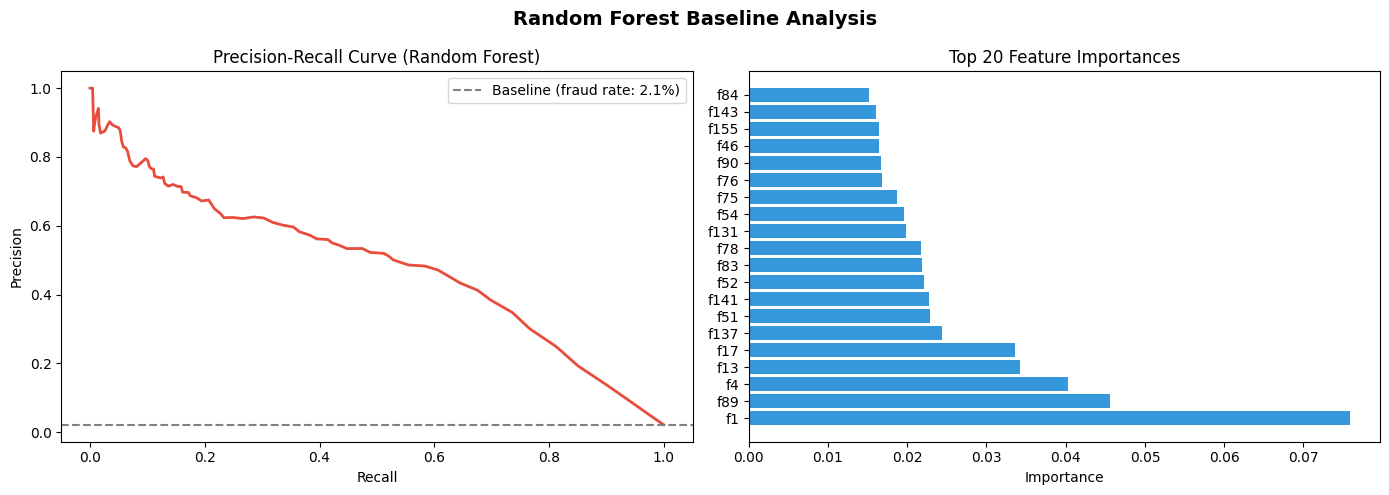

In [4]:
# Precision-Recall curve (more informative than ROC for imbalanced data)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve
axes[0].plot(recall, precision, color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (Random Forest)')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', 
                label=f'Baseline (fraud rate: {y_test.mean()*100:.1f}%)')
axes[0].legend()

# Feature importance (top 20)
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]
axes[1].barh(range(20), importances[top_idx], color='#3498db')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'f{i}' for i in top_idx])
axes[1].set_title('Top 20 Feature Importances')
axes[1].set_xlabel('Importance')

plt.suptitle('Random Forest Baseline Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Conclusions

The Random Forest achieves a strong ROC-AUC of 0.95, but recall on illicit nodes is only 11%:
it misses 9 out of 10 fraudulent transactions.

Feature importance reveals that **f1 (timestep)** is by far the most predictive feature,
confirming that fraud has strong temporal patterns. The remaining top features (f84, f143, f155)
correspond to aggregated neighborhood statistics, indirect evidence that graph structure matters.

This sets our benchmark: any GNN worth building must improve recall on illicit nodes
while maintaining reasonable precision. ROC-AUC alone is not enough.